In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score, 
                             precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report)
from sklearn.datasets import fetch_openml
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("CAR PRICE PREDICTION")

# Load dataset
auto_mpg = fetch_openml(name='autoMpg', version=1, as_frame=True)
df = auto_mpg.frame

df.columns = ['cylinders','displacement','horsepower','weight','acceleration','model_year','origin','class']

print("Dataset Loaded")
print(f"    Shape:{df.shape}")
print(f"    Features:{df.columns.tolist()}")

print("Dataset Info:")
print(df.info)

print("First 5 rows")
print(df.head())

CAR PRICE PREDICTION
Dataset Loaded
    Shape:(398, 8)
    Features:['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'class']
Dataset Info:
<bound method DataFrame.info of     cylinders  displacement  horsepower  weight  acceleration model_year  \
0           8         307.0       130.0    3504          12.0         70   
1           8         350.0       165.0    3693          11.5         70   
2           8         318.0       150.0    3436          11.0         70   
3           8         304.0       150.0    3433          12.0         70   
4           8         302.0       140.0    3449          10.5         70   
..        ...           ...         ...     ...           ...        ...   
393         4         140.0        86.0    2790          15.6         82   
394         4          97.0        52.0    2130          24.6         82   
395         4         135.0        84.0    2295          11.6         82   
396         4         1

In [3]:
# Basic Statistics
print("\nStatistical Summary:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Handle missing values
print("\nHandling Missing Values...")
# Drop rows with missing values
df_clean = df.dropna()
print(f"Rows after dropping missing values: {df_clean.shape[0]}")

# Convert data types
df_clean['origin'] = df_clean['origin'].astype('category')
df_clean['cylinders'] = df_clean['cylinders'].astype('int')

print("\nData types after conversion:")
print(df_clean.dtypes)


Statistical Summary:


       displacement  horsepower       weight  acceleration       class
count    398.000000  392.000000   398.000000    398.000000  398.000000
mean     193.425879  104.469388  2970.424623     15.568090   23.514573
std      104.269838   38.491160   846.841774      2.757689    7.815984
min       68.000000   46.000000  1613.000000      8.000000    9.000000
25%      104.250000   75.000000  2223.750000     13.825000   17.500000
50%      148.500000   93.500000  2803.500000     15.500000   23.000000
75%      262.000000  126.000000  3608.000000     17.175000   29.000000
max      455.000000  230.000000  5140.000000     24.800000   46.600000

Missing Values:
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
class           0
dtype: int64

Handling Missing Values...
Rows after dropping missing values: 392

Data types after conversion:
cylinders          int64
displacement     float64
horsepower       float64
weight        


Exploratory Data Analysis
Available columns: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'class']
Columns after cleanup: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'mpg']
Dataset shape: (392, 8)


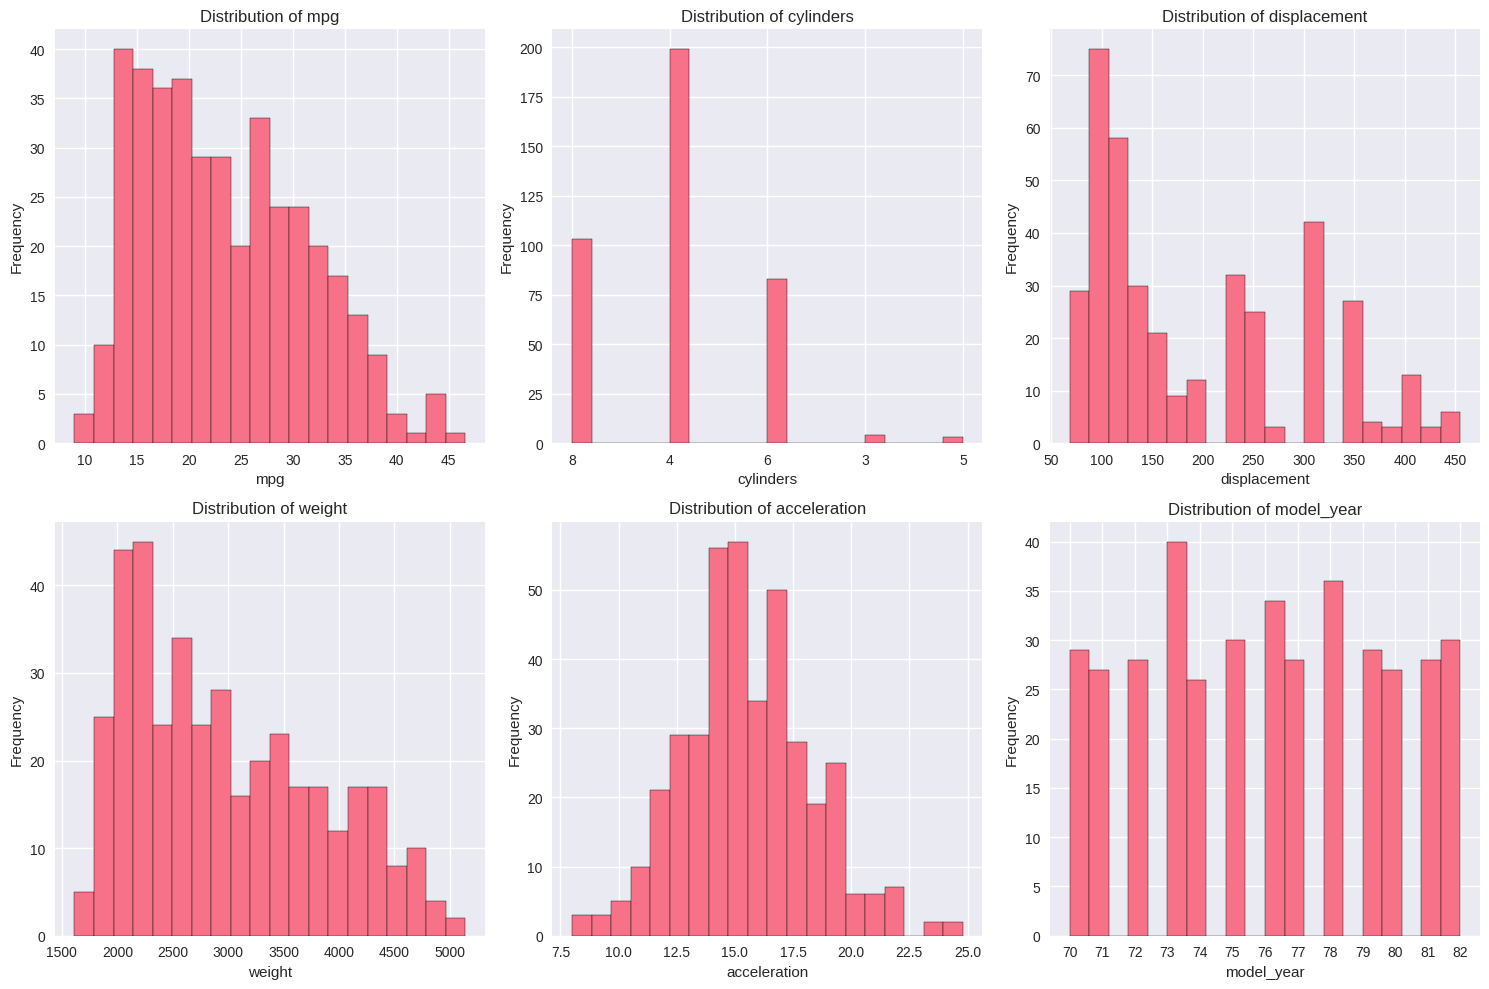


Correlation Matrix:


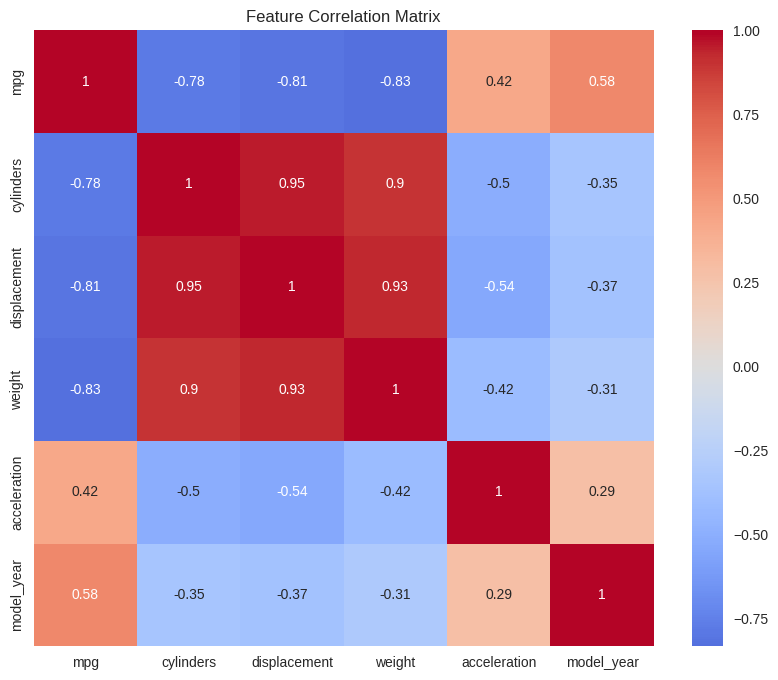


Key Relationships:


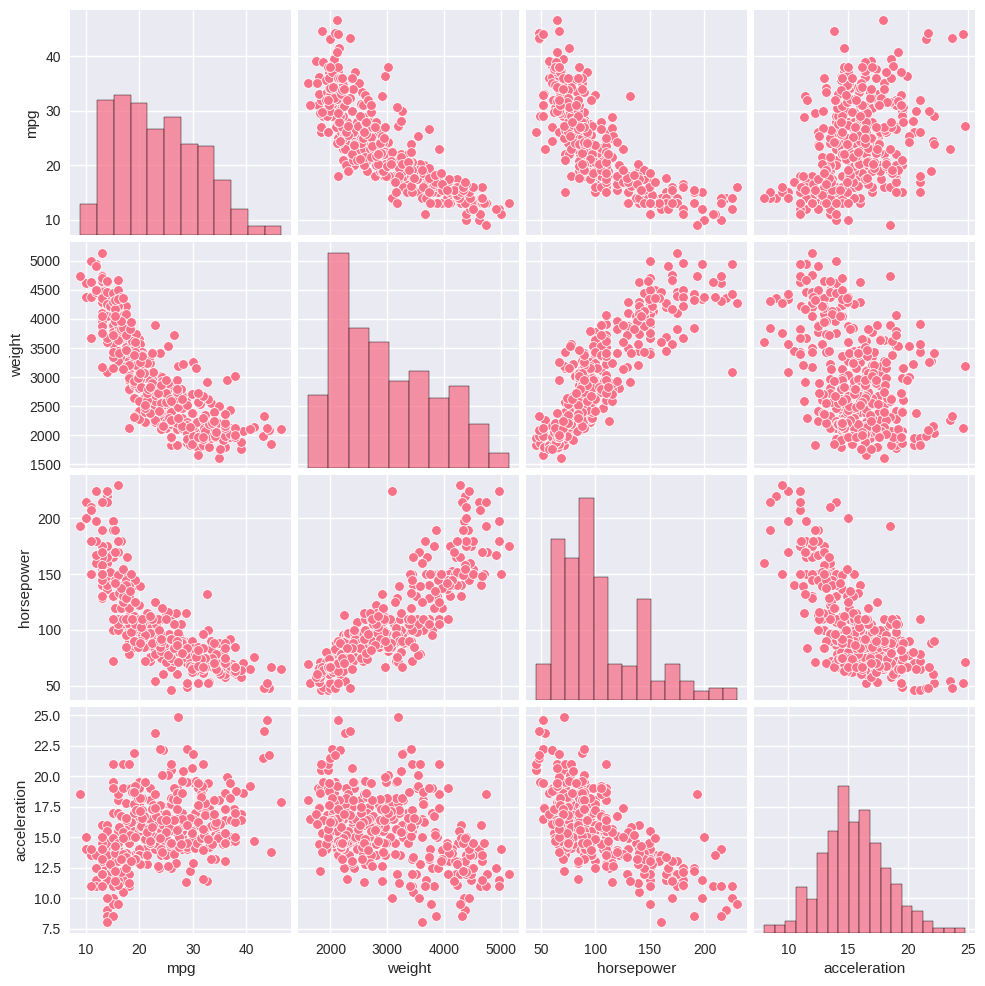

In [4]:
# Exploratory Data Analysis
print("\nExploratory Data Analysis")

# First ensure we have the clean dataframe
df_clean = df.dropna()

# Check column names to see what we actually have
print("Available columns:", df_clean.columns.tolist())

# If 'class' exists but 'mpg' doesn't, rename it
if 'class' in df_clean.columns and 'mpg' not in df_clean.columns:
    df_clean.rename(columns={'class': 'mpg'}, inplace=True)

# If neither exists, use the first column as target
if 'mpg' not in df_clean.columns:
    # The AutoMPG dataset usually has target as first column
    df_clean.columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 
                        'weight', 'acceleration', 'model_year', 'origin', 'car_name']
    df_clean = df_clean.drop('car_name', axis=1)

print("Columns after cleanup:", df_clean.columns.tolist())
print(f"Dataset shape: {df_clean.shape}")

# Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

numeric_cols = ['mpg', 'cylinders', 'displacement', 'weight', 'acceleration', 'model_year']
for i, col in enumerate(numeric_cols):
    if col in df_clean.columns:
        df_clean[col].hist(ax=axes[i], bins=20, edgecolor='black')
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')
    else:
        axes[i].set_title(f'{col} not found')

plt.tight_layout()
plt.show()

# Correlation matrix
print("\nCorrelation Matrix:")
available_numeric = [col for col in numeric_cols if col in df_clean.columns]
correlation_matrix = df_clean[available_numeric].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

# Pairplot for key features
print("\nKey Relationships:")
available_features = [col for col in ['mpg', 'weight', 'horsepower', 'acceleration'] 
                     if col in df_clean.columns]
if len(available_features) >= 2:
    sns.pairplot(df_clean[available_features])
    plt.show()
else:
    print("Not enough features available for pairplot")
plt.show()


Outlier Detection:
Outliers in MPG: 0 observations


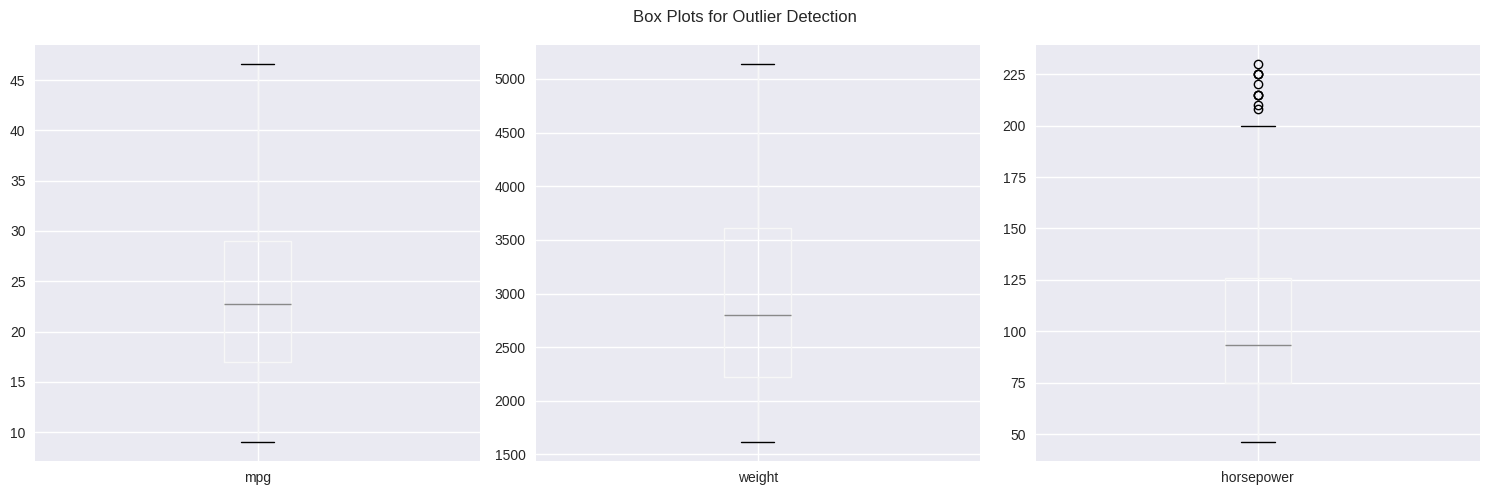


Removing outliers...
Dataset shape after removing outliers: (392, 8)


In [5]:
# Outlier Detection
print("\nOutlier Detection:")

def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check outliers in mpg
if 'mpg' not in df_clean.columns:
    if 'class' in df_clean.columns:
        df_clean.rename(columns={'class': 'mpg'}, inplace=True)
    else:
        raise KeyError("Neither 'mpg' nor 'class' column found for outlier detection")

mpg_outliers, lower, upper = detect_outliers_iqr(df_clean, 'mpg')
print(f"Outliers in MPG: {len(mpg_outliers)} observations")

# Box plots for outlier visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
df_clean.boxplot(column=['mpg'], ax=axes[0])
df_clean.boxplot(column=['weight'], ax=axes[1])
df_clean.boxplot(column=['horsepower'], ax=axes[2])
plt.suptitle('Box Plots for Outlier Detection')
plt.tight_layout()
plt.show()

# Remove outliers
print("\nRemoving outliers...")
df_clean = df_clean[(df_clean['mpg'] >= lower) & (df_clean['mpg'] <= upper)]
print(f"Dataset shape after removing outliers: {df_clean.shape}")

In [6]:
# Feature Engineering
print("\nFeature Engineering:")

df_eng = df_clean.copy()

# Create new features
df_eng['horsepower_per_weight'] = df_eng['horsepower'] / df_eng['weight']
numeric_cols = ['displacement', 'horsepower', 'weight', 'cylinders', 'mpg']
df_eng[numeric_cols] = df_eng[numeric_cols].apply(pd.to_numeric, errors='coerce')

df_eng['displacement_per_cylinder'] = df_eng['displacement'] / df_eng['cylinders']
df_eng['power_to_weight_ratio'] = df_eng['horsepower'] / (df_eng['weight'] / 1000)
df_eng['mpg_per_hp'] = df_eng['mpg'] / df_eng['horsepower']

# Create target categories for classification
df_eng['mpg_category'] = pd.cut(df_eng['mpg'], 
                                bins=[0, 20, 30, 50], 
                                labels=['Low', 'Medium', 'High'])

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df_eng['origin_encoded'] = label_encoder.fit_transform(df_eng['origin'])

print(f"New features added: {len(df_eng.columns) - len(df_clean.columns)} features")
print(f"Total features: {len(df_eng.columns)}")
print("\nFeature names:")
print(df_eng.columns.tolist())


Feature Engineering:


New features added: 6 features
Total features: 14

Feature names:
['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'mpg', 'horsepower_per_weight', 'displacement_per_cylinder', 'power_to_weight_ratio', 'mpg_per_hp', 'mpg_category', 'origin_encoded']


In [7]:
# Feature Scaling Demonstration
print("\nFeature Scaling Demonstration:")

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Select features for scaling
scale_features = ['horsepower', 'weight', 'acceleration']

# StandardScaler
scaler_standard = StandardScaler()
df_eng['horsepower_standard'] = scaler_standard.fit_transform(df_eng[['horsepower']])

# MinMaxScaler
scaler_minmax = MinMaxScaler()
df_eng['weight_minmax'] = scaler_minmax.fit_transform(df_eng[['weight']])

print("Original horsepower:")
print(f"  Mean: {df_eng['horsepower'].mean():.2f}")
print(f"  Std: {df_eng['horsepower'].std():.2f}")

print("\nScaled (StandardScaler):")
print(f"  Mean: {df_eng['horsepower_standard'].mean():.2f}")
print(f"  Std: {df_eng['horsepower_standard'].std():.2f}")

print("\nOriginal weight:")
print(f"  Min: {df_eng['weight'].min():.2f}")
print(f"  Max: {df_eng['weight'].max():.2f}")

print("\nScaled (MinMaxScaler):")
print(f"  Min: {df_eng['weight_minmax'].min():.2f}")
print(f"  Max: {df_eng['weight_minmax'].max():.2f}")


Feature Scaling Demonstration:


Original horsepower:
  Mean: 104.47
  Std: 38.49

Scaled (StandardScaler):
  Mean: -0.00
  Std: 1.00

Original weight:
  Min: 1613.00
  Max: 5140.00

Scaled (MinMaxScaler):
  Min: 0.00
  Max: 1.00


In [8]:
# Logistic Regression
print("\nLogistic Regression:")

from sklearn.linear_model import LogisticRegression

# Scale features
scaler_clf = StandardScaler()
X_clf = df_eng[['weight', 'horsepower', 'acceleration', 'origin_encoded',
                'horsepower_per_weight', 'displacement_per_cylinder']]
y_clf = df_eng['mpg_category']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

# Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_clf_scaled, y_train_clf)
y_pred_log = log_reg.predict(X_test_clf_scaled)

print("Logistic Regression Results:")
print(f"  Accuracy: {accuracy_score(y_test_clf, y_pred_log):.3f}")
print(f"  Classification Report:")
print(classification_report(y_test_clf, y_pred_log))


Logistic Regression:
Logistic Regression Results:
  Accuracy: 0.734
  Classification Report:
              precision    recall  f1-score   support

        High       0.75      0.53      0.62        17
         Low       0.87      0.81      0.84        32
      Medium       0.62      0.77      0.69        30

    accuracy                           0.73        79
   macro avg       0.75      0.70      0.72        79
weighted avg       0.75      0.73      0.73        79




LOGISTIC REGRESSION - ADVANCED VISUALIZATION


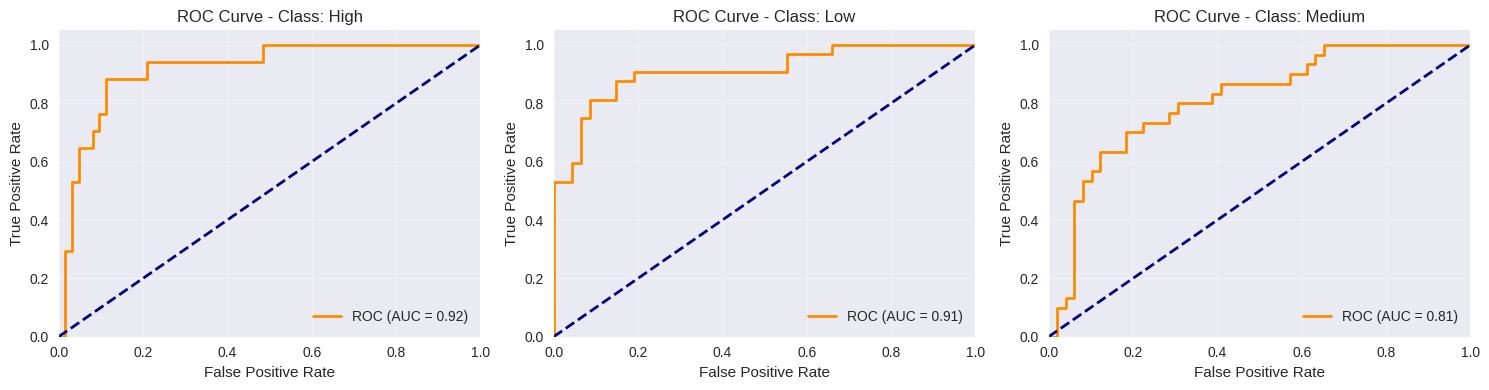

In [9]:
# Logistic Regression - ROC Curves and Performance Visualization
print("\n" + "="*60)
print("LOGISTIC REGRESSION - ADVANCED VISUALIZATION")
print("="*60)

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Prepare for ROC curves (one-vs-rest)
# Convert labels to numeric
le = LabelEncoder()
y_test_numeric = le.fit_transform(y_test_clf)
y_pred_proba = log_reg.predict_proba(X_test_clf_scaled)

# Plot ROC curves for each class
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
classes = le.classes_

for i, class_name in enumerate(classes):
    # Create binary labels for this class
    y_binary = (y_test_numeric == i).astype(int)
    y_score = y_pred_proba[:, i]
    
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_binary, y_score)
    roc_auc = auc(fpr, tpr)
    
    # Plot
    axes[i].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    axes[i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].set_title(f'ROC Curve - Class: {class_name}')
    axes[i].legend(loc="lower right")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


CONFUSION MATRIX


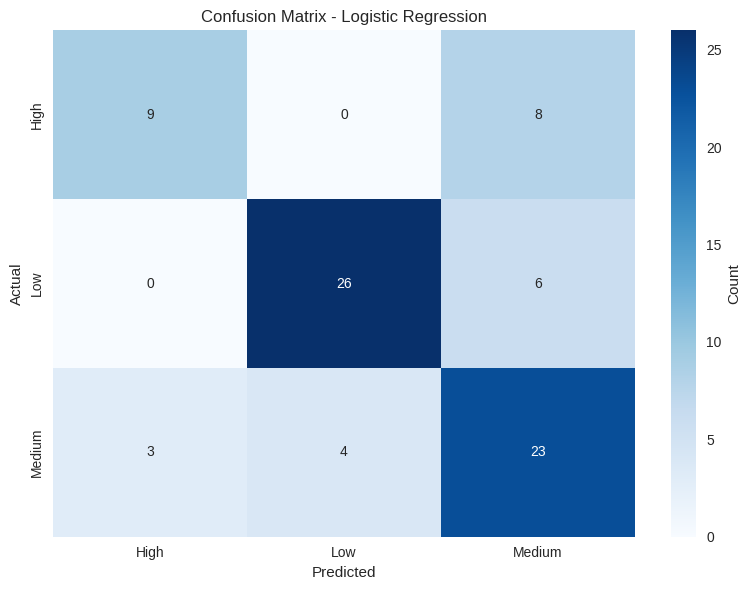


Detailed Classification Metrics:
----------------------------------------
Overall Accuracy: 0.734
Macro F1-Score: 0.715
Weighted F1-Score: 0.734

Per-class metrics:
              precision    recall  f1-score   support

        High       0.75      0.53      0.62        17
         Low       0.87      0.81      0.84        32
      Medium       0.62      0.77      0.69        30

    accuracy                           0.73        79
   macro avg       0.75      0.70      0.72        79
weighted avg       0.75      0.73      0.73        79



In [10]:
# Confusion Matrix Heatmap
print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate confusion matrix
cm = confusion_matrix(y_test_clf, y_pred_log)

# Plot with seaborn for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Print classification metrics in detail
print("\nDetailed Classification Metrics:")
print("-" * 40)
print(f"Overall Accuracy: {accuracy_score(y_test_clf, y_pred_log):.3f}")
print(f"Macro F1-Score: {f1_score(y_test_clf, y_pred_log, average='macro'):.3f}")
print(f"Weighted F1-Score: {f1_score(y_test_clf, y_pred_log, average='weighted'):.3f}")
print("\nPer-class metrics:")
print(classification_report(y_test_clf, y_pred_log))


FEATURE IMPORTANCE ANALYSIS


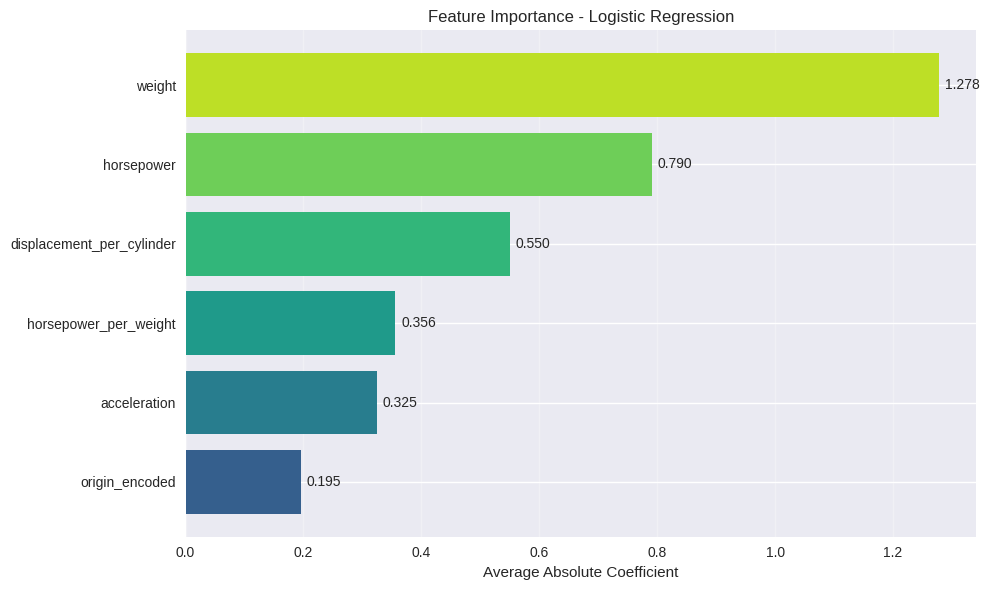


Per-class coefficients (indicating feature influence for each category):

Class: High
  weight: -1.409
  horsepower: -1.116
  displacement_per_cylinder: -0.825
  horsepower_per_weight: -0.534
  acceleration: -0.438

Class: Low
  weight: 1.916
  horsepower: 1.186
  displacement_per_cylinder: 0.699
  origin_encoded: -0.079
  acceleration: -0.048

Class: Medium
  weight: -0.508
  horsepower_per_weight: 0.504
  acceleration: 0.487
  origin_encoded: -0.214
  displacement_per_cylinder: 0.126


In [11]:
# Feature Importance Analysis for Logistic Regression
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get feature coefficients
feature_names = X_clf.columns
coefficients = log_reg.coef_

# For multi-class, average absolute coefficients
avg_coef = np.mean(np.abs(coefficients), axis=0)

# Create DataFrame for visualization
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': avg_coef
}).sort_values('Coefficient', ascending=True)

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'], 
               color=plt.cm.viridis(np.linspace(0.3, 0.9, len(coef_df))))

# Add value labels
for i, (v, bar) in enumerate(zip(coef_df['Coefficient'], bars)):
    ax.text(v + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{v:.3f}', va='center', fontsize=10)

ax.set_xlabel('Average Absolute Coefficient')
ax.set_title('Feature Importance - Logistic Regression')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Show per-class coefficients
print("\nPer-class coefficients (indicating feature influence for each category):")
for i, class_name in enumerate(classes):
    print(f"\nClass: {class_name}")
    coef_dict = dict(zip(feature_names, coefficients[i]))
    sorted_coef = sorted(coef_dict.items(), key=lambda x: abs(x[1]), reverse=True)
    for feature, coef in sorted_coef[:5]:
        print(f"  {feature}: {coef:.3f}")